# EDA: Students Performance Dataset

This notebook performs exploratory data analysis (EDA) on the Students Performance dataset.


## Notebook Metadata
- Project: Students Performance EDA
- Notebook: `EDA_Students_Performance.ipynb`
- Dataset: `notebook/Data/data.csv`
- Generated on: 2026-03-08
- Objective: Understand score distributions, relationships, and category-wise performance patterns.

### Column Dictionary
- `gender`: Student gender category (`female`, `male`).
- `race/ethnicity`: Student group label (`group A` to `group E`).
- `parental level of education`: Highest education level reported for parents (e.g., high school, bachelor's degree, master's degree).
- `lunch`: Lunch type (`standard`, `free/reduced`) used as a socioeconomic proxy.
- `test preparation course`: Whether student completed test prep (`completed`, `none`).
- `math score`: Math exam score (0-100).
- `reading score`: Reading exam score (0-100).
- `writing score`: Writing exam score (0-100).
- `average_score`: Engineered feature in this notebook, mean of math, reading, and writing scores.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)


In [2]:
# Load data
candidate_paths = [
    Path('notebook/Data/data.csv'),
    Path('Data/data.csv'),
]

file_path = next((p for p in candidate_paths if p.exists()), None)
if file_path is None:
    raise FileNotFoundError('Could not locate data.csv in expected paths.')

df = pd.read_csv(file_path)

print(f'Loaded from: {file_path}')
print(f'Shape: {df.shape}')
display(df.head())


Loaded from: Data\data.csv
Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Observations
- Dataset loaded successfully from local path.
- Total records: 1000; original raw columns: 8.


In [3]:
# Data overview
print('Column names:')
print(df.columns.tolist())
print()
print('Data types:')
display(df.dtypes.to_frame('dtype'))

print()
print('Summary info:')
df.info()


Column names:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Data types:


,dtype
gender,str
race/ethnicity,str
parental level of education,str
lunch,str
test preparation course,str
math score,int64
reading score,int64
writing score,int64



Summary info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


### Observations
- The dataset contains 5 categorical columns and 3 numerical score columns.
- Numerical fields are exam scores and already in numeric format.


In [4]:
# Missing values and duplicates
missing = df.isnull().sum().to_frame('missing_count')
missing['missing_percent'] = (missing['missing_count'] / len(df) * 100).round(2)
display(missing)

duplicate_count = df.duplicated().sum()
print(f'Duplicated rows: {duplicate_count}')


,missing_count,missing_percent
gender,0,0.0
race/ethnicity,0,0.0
parental level of education,0,0.0
lunch,0,0.0
test preparation course,0,0.0
math score,0,0.0
reading score,0,0.0
writing score,0,0.0


Duplicated rows: 0


### Observations
- Missing values: 0 across all columns.
- Duplicate rows: 0, so no row-level cleanup is required.


In [5]:
# Statistical summary
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


### Observations
- Mean scores are in the high-60s: math 66.09, reading 69.17, writing 68.05.
- Score spread is moderate (std around 14-15).


In [6]:
# Categorical feature distributions
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f'Value counts for {col}:')
    display(df[col].value_counts().to_frame('count'))


Value counts for gender:


,count
gender,
female,518
male,482


Value counts for race/ethnicity:


,count
race/ethnicity,
group C,319
group D,262
group B,190
group E,140
group A,89


Value counts for parental level of education:


,count
parental level of education,
some college,226
associate's degree,222
high school,196
some high school,179
bachelor's degree,118
master's degree,59


Value counts for lunch:


,count
lunch,
standard,645
free/reduced,355


Value counts for test preparation course:


,count
test preparation course,
none,642
completed,358


### Observations
- Categorical coverage: gender (2), race/ethnicity (5), parental education (6), lunch (2), test prep (2).
- Category sizes are sufficient for comparison analysis.


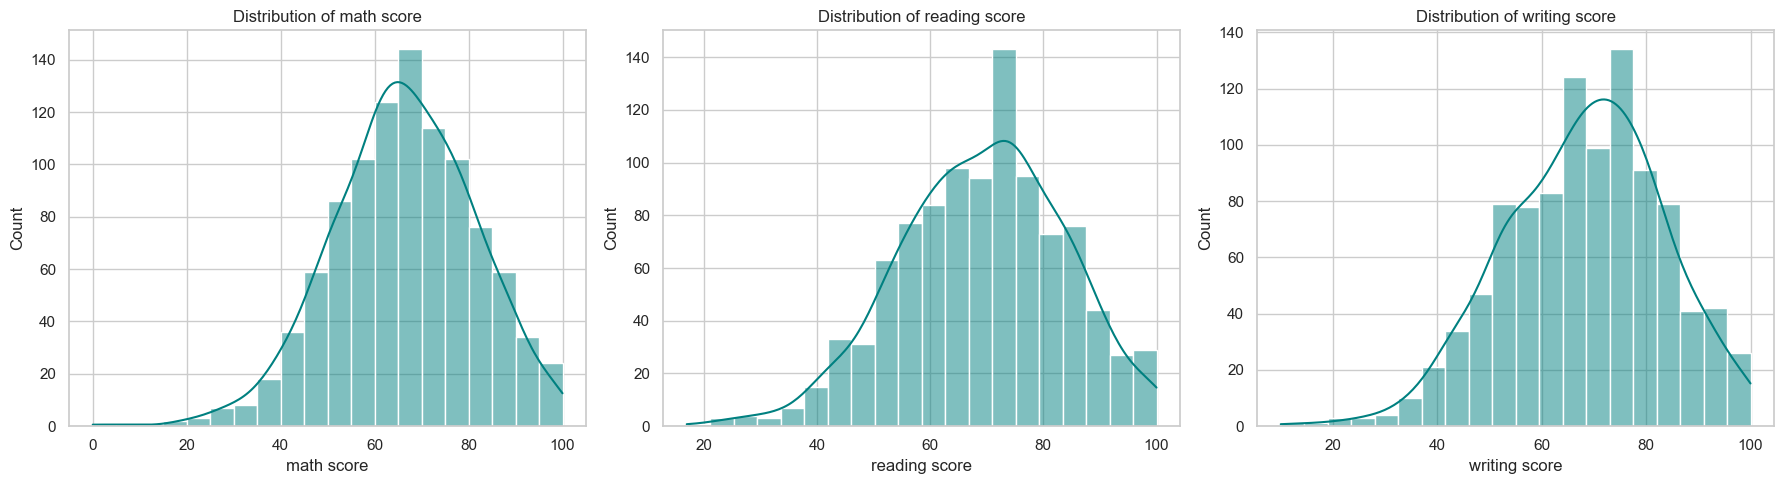

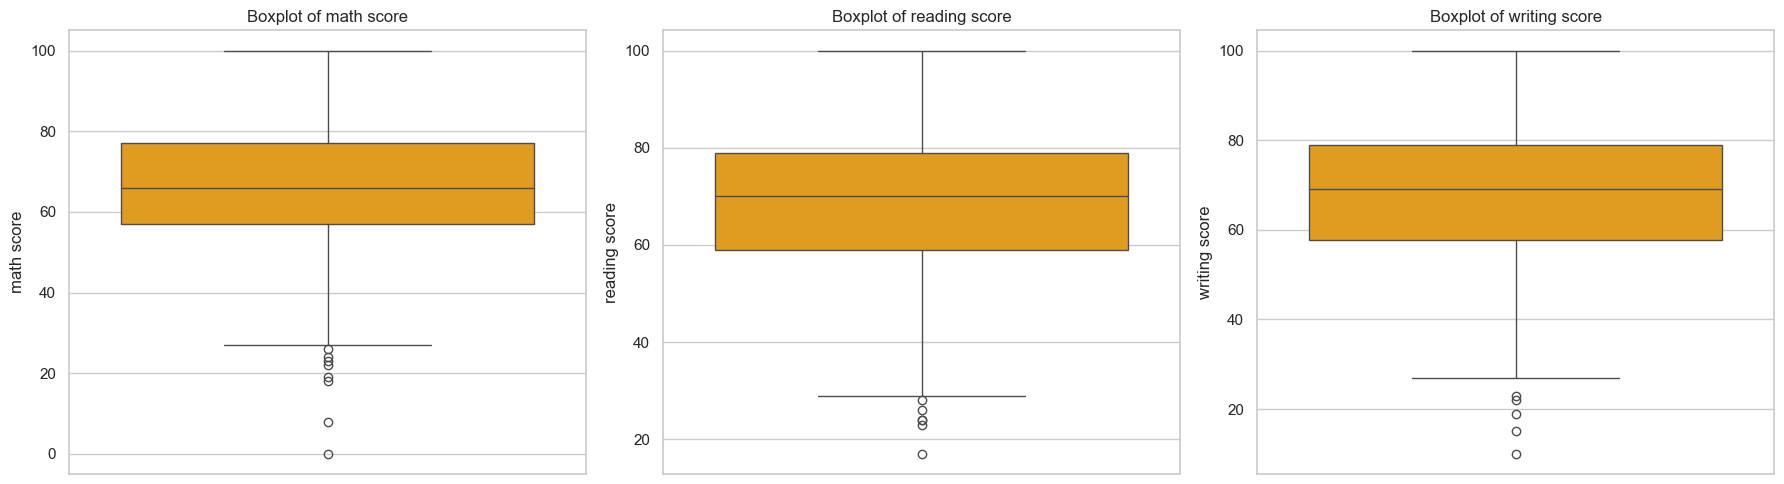

In [7]:
# Distribution of scores
score_cols = ['math score', 'reading score', 'writing score']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(score_cols):
    sns.histplot(df[col], kde=True, bins=20, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(score_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='orange')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


### Observations
- Reading and writing are centered slightly above math.
- Boxplots indicate a few low-end extremes but no severe distortion.


,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


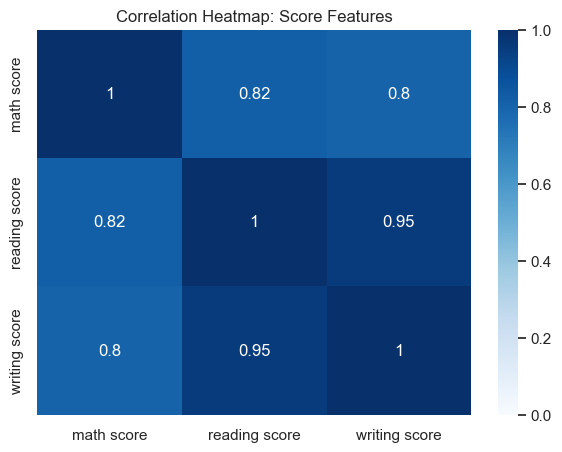

In [8]:
# Correlation analysis
corr = df[score_cols].corr()
display(corr)

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='Blues', vmin=0, vmax=1)
plt.title('Correlation Heatmap: Score Features')
plt.show()


### Observations
- All score pairs are strongly positively correlated.
- Strongest relationship: reading vs writing (0.955).


In [9]:
# Create average score for richer analysis
df['average_score'] = df[score_cols].mean(axis=1)
display(df[['math score', 'reading score', 'writing score', 'average_score']].head())


,math score,reading score,writing score,average_score
0,72,72,74,72.666667
1,69,90,88,82.333333
2,90,95,93,92.666667
3,47,57,44,49.333333
4,76,78,75,76.333333


### Observations
- Added `average_score` as an overall performance indicator.
- Overall mean `average_score` is 67.77.


In [10]:
# Group-wise performance by key categorical features
key_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

for feature in key_features:
    summary = (
        df.groupby(feature)[['math score', 'reading score', 'writing score', 'average_score']]
        .mean()
        .sort_values('average_score', ascending=False)
        .round(2)
    )
    print(f'Average scores by {feature}:')
    display(summary)


Average scores by gender:


,math score,reading score,writing score,average_score
gender,,,,
female,63.63,72.61,72.47,69.57
male,68.73,65.47,63.31,65.84


Average scores by race/ethnicity:


,math score,reading score,writing score,average_score
race/ethnicity,,,,
group E,73.82,73.03,71.41,72.75
group D,67.36,70.03,70.15,69.18
group C,64.46,69.10,67.83,67.13
group B,63.45,67.35,65.60,65.47
group A,61.63,64.67,62.67,62.99


Average scores by parental level of education:


,math score,reading score,writing score,average_score
parental level of education,,,,
master's degree,69.75,75.37,75.68,73.60
bachelor's degree,69.39,73.00,73.38,71.92
associate's degree,67.88,70.93,69.90,69.57
some college,67.13,69.46,68.84,68.48
some high school,63.50,66.94,64.89,65.11
high school,62.14,64.70,62.45,63.10


Average scores by lunch:


,math score,reading score,writing score,average_score
lunch,,,,
standard,70.03,71.65,70.82,70.84
free/reduced,58.92,64.65,63.02,62.20


Average scores by test preparation course:


,math score,reading score,writing score,average_score
test preparation course,,,,
completed,69.70,73.89,74.42,72.67
none,64.08,66.53,64.50,65.04


### Observations
- Female average score (69.57) is higher than male (65.84).
- Completed test prep (72.67) outperforms none (65.04).
- Standard lunch (70.84) outperforms free/reduced (62.20).


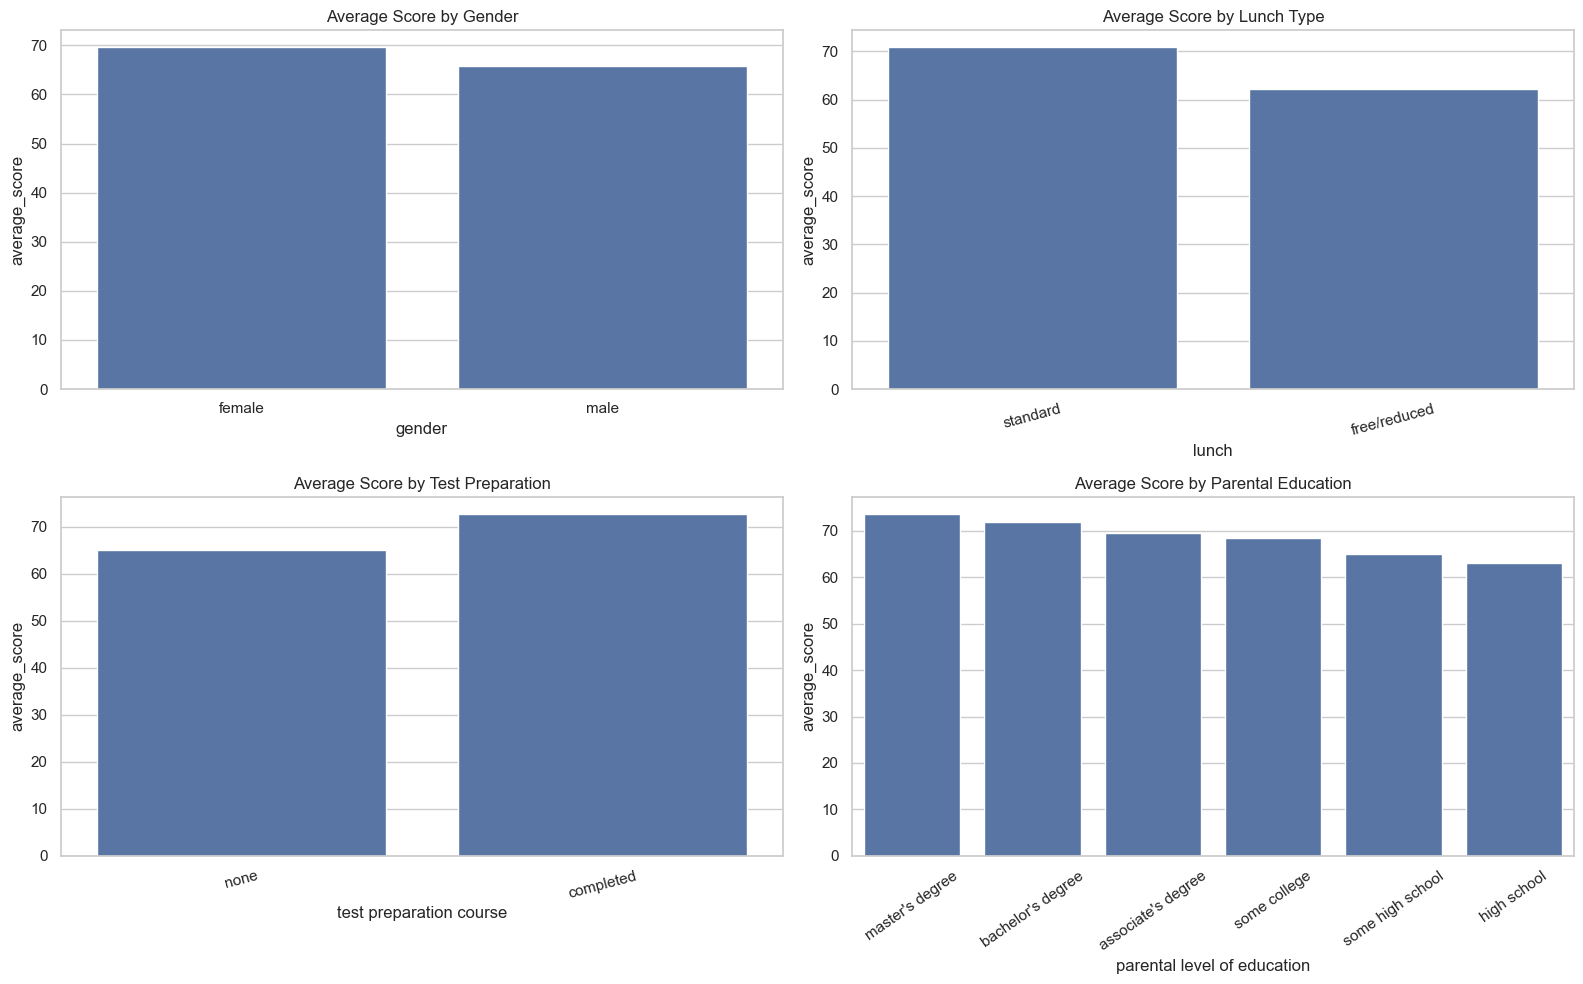

In [11]:
# Visualization: average score by category
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.barplot(data=df, x='gender', y='average_score', estimator=np.mean, errorbar=None, ax=axes[0, 0])
axes[0, 0].set_title('Average Score by Gender')

sns.barplot(data=df, x='lunch', y='average_score', estimator=np.mean, errorbar=None, ax=axes[0, 1])
axes[0, 1].set_title('Average Score by Lunch Type')
axes[0, 1].tick_params(axis='x', rotation=15)

sns.barplot(data=df, x='test preparation course', y='average_score', estimator=np.mean, errorbar=None, ax=axes[1, 0])
axes[1, 0].set_title('Average Score by Test Preparation')
axes[1, 0].tick_params(axis='x', rotation=15)

order = df.groupby('parental level of education')['average_score'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='parental level of education', y='average_score', order=order, estimator=np.mean, errorbar=None, ax=axes[1, 1])
axes[1, 1].set_title('Average Score by Parental Education')
axes[1, 1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


### Observations
- Visual comparisons confirm strongest gaps for lunch type and test preparation.
- Higher parental education levels generally align with higher average scores.


In [12]:
# Outlier counts with IQR rule
outlier_summary = {}
for col in score_cols + ['average_score']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': int(outliers)
    }

display(pd.DataFrame(outlier_summary).T)


,lower_bound,upper_bound,outlier_count
math score,27.00,107.00,8.0
reading score,29.00,109.00,6.0
writing score,25.88,110.88,5.0
average_score,29.33,106.67,6.0


### Observations
- Outlier counts are low: math 8, reading 6, writing 5, average_score 6.
- Outlier volume is small relative to 1000 rows.


## Conclusion

This EDA notebook checks data quality, score distributions, feature correlations, and category-wise performance.
Use these findings to guide feature engineering and model development in the training pipeline.


## All Observations
Consolidated observations from all EDA sections:

- Dataset loaded successfully from local path.
- Total records: 1000; original raw columns: 8.
- The dataset contains 5 categorical columns and 3 numerical score columns.
- Numerical fields are exam scores and are already in usable numeric format.
- Missing values: 0 across all columns.
- Duplicate rows: 0, so no row-level cleanup is required.
- Mean scores are around the high-60s: math 66.09, reading 69.17, writing 68.05.
- Score spread is moderate (std ~14-15), indicating variation across students.
- Categorical coverage: gender (2), race/ethnicity (5), parental education (6), lunch (2), test prep (2).
- Category counts are reasonably distributed for comparison analysis.
- Reading and writing generally cluster slightly higher than math.
- Boxplots show a few low-end extreme values but no severe distribution collapse.
- Strong positive relationships exist between all score pairs.
- Strongest link: reading vs writing (0.955), suggesting similar performance behavior.
- `average_score` is added as an aggregate performance indicator.
- Overall mean average score is 67.77.
- Female students have higher average score (69.57) than male students (65.84).
- Test prep completion shows a clear uplift: completed (72.67) vs none (65.04).
- Standard lunch group performs notably better (70.84) than free/reduced (62.20).
- Bar charts confirm the strongest performance gaps for lunch type and test preparation.
- Higher parental education levels generally align with higher student average scores.
- Outliers are limited: math (8), reading (6), writing (5), average_score (6).
- Outlier volume is low relative to dataset size, so robust models should handle this well.
- Top-performing groups: female, standard lunch, completed test prep, and parental education at master's level.
- These patterns can inform feature importance checks and fairness-aware model evaluation.
